# Heart Disease

This project aims to evaluate the ability to apply a complete data mining and machine learning pipeline on a real-world dataset. The chosen dataset is the Heart Disease dataset from the UCI Machine Learning Repository, which contains clinical information about patients.


The objective of this project is to predict the presence of heart disease based on medical attributes. The target variable `num` originally contains multiple levels (0–4), where:
* 0 indicates absence of heart disease
* 1–4 indicate varying degrees of presence

For this analysis, the problem is formulated as a binary classification task, where:

* 0 → No heart disease

* 1 → Presence of heart disease

In [1]:
pip install ucimlrepo

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from matplotlib.lines import lineStyles
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import numpy as np
import warnings
import xgboost as xgb
warnings.filterwarnings("ignore")

## 1. Data Loading and Processing

The dataset is loaded and inspected to understand its structure, feature names, and data types.

In [3]:
# Data loading
heart_disease = fetch_ucirepo(id=45)

In [4]:
# Define the features and the target
X = heart_disease.data.features
y = heart_disease.data.targets

### Features Dataset

It consists of 13 clinical attributes that the model uses to identify physiological patterns associated with cardiac health.

In [5]:
# Read 5 lines of the features
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [6]:
# Summary of the dataset
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


In [7]:
# Check missing values
X.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


We use the mode (most frequent value) for strictly categorical data like `thal`, and the median for the ordinal feature `ca` to ensure the central tendency is preserved without being skewed by potential outliers.

In [8]:
# Fill the ordinal feature with the median
X['ca'] = X['ca'].fillna(X['ca'].median())

# Fill the categorical feature with the mode
X['thal'] = X['thal'].fillna(X['thal'].mode()[0])

### Target Dataset

It contains the target column, where (1-4) indicates the presence of heart disease and 0 indicates its absence, serving as the ground truth for training and evaluation.

In [9]:
# Read 5 lines of the target
y.head()

,num
0,0
1,2
2,1
3,0
4,0


In [10]:
# Summary of the dataset
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   num     303 non-null    int64
dtypes: int64(1)
memory usage: 2.5 KB


The target variable `num` is converted into a binary classification problem by mapping all values greater than 0 to 1, and 0 to 0.

In [11]:
# Convert target into binary classification
y['num'] = y['num'].apply(lambda x: 1 if x > 0 else 0)

## 2. Exploratory Data Analysis

Exploratory Data Analysis is performed to examine the distribution of variables, and detect patterns. This step helps build intuition about the data and guides preprocessing and modeling decisions.

### Numerical Features

* **age:** Age of the patient in years, an important risk factor for heart disease.
* **trestbps:** Resting blood pressure (mm Hg), where higher values may indicate hypertension.
* **chol:** Serum cholesterol (mg/dl), with elevated levels linked to heart disease risk.
* **thalach:** Maximum heart rate achieved, often inversely related to heart disease presence.
* **oldpeak:** ST depression induced by exercise, reflecting potential abnormalities in heart function.
* **ca:** Number of major vessels (0–3) colored by fluoroscopy, indicating the extent of vessel blockage.



In [12]:
# Numerical features
num = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

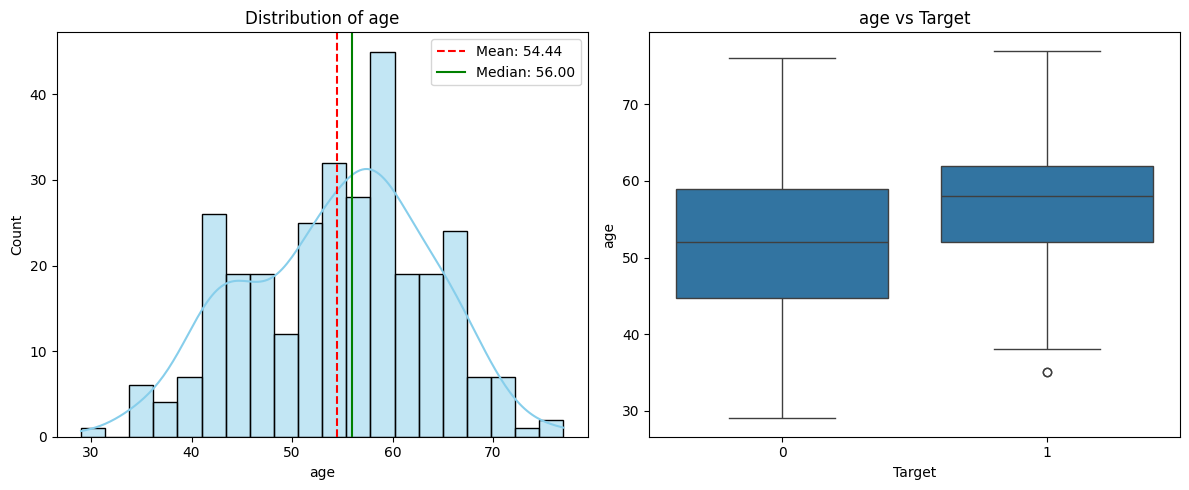

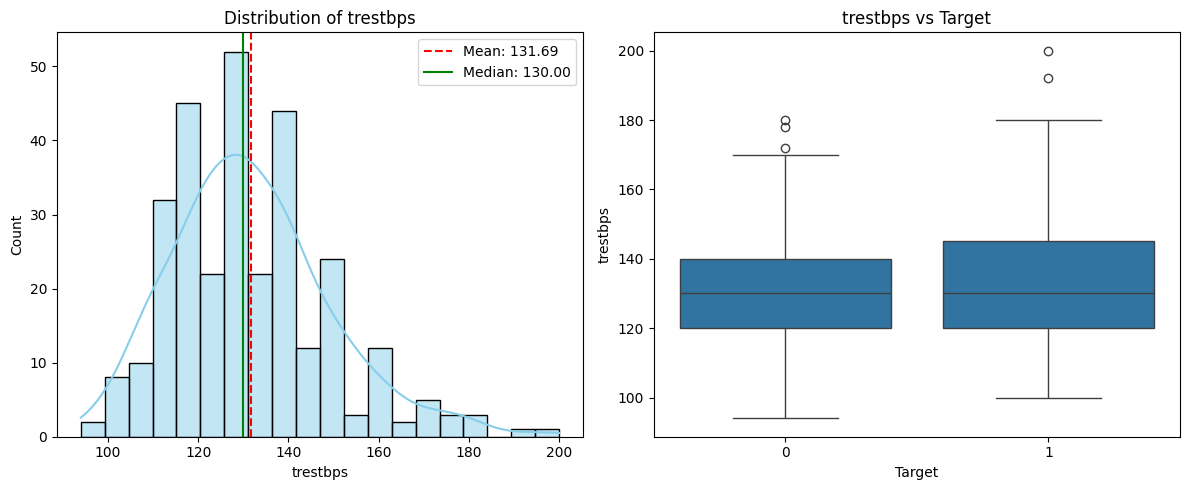

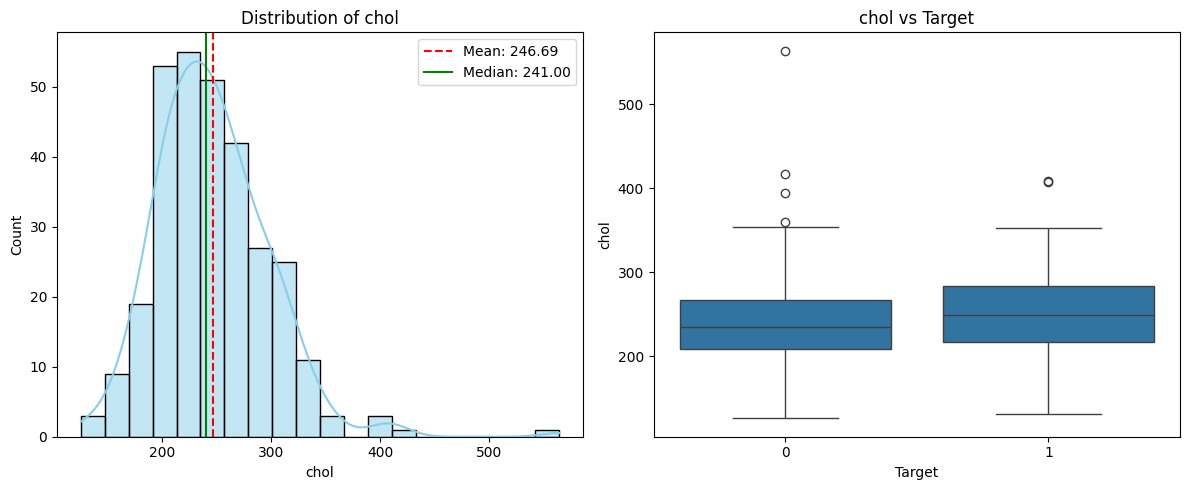

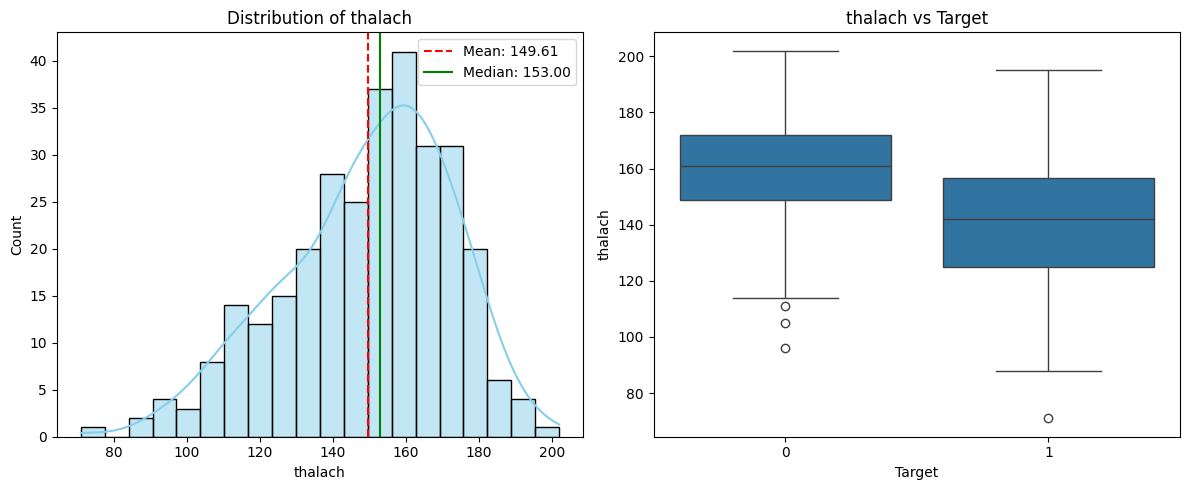

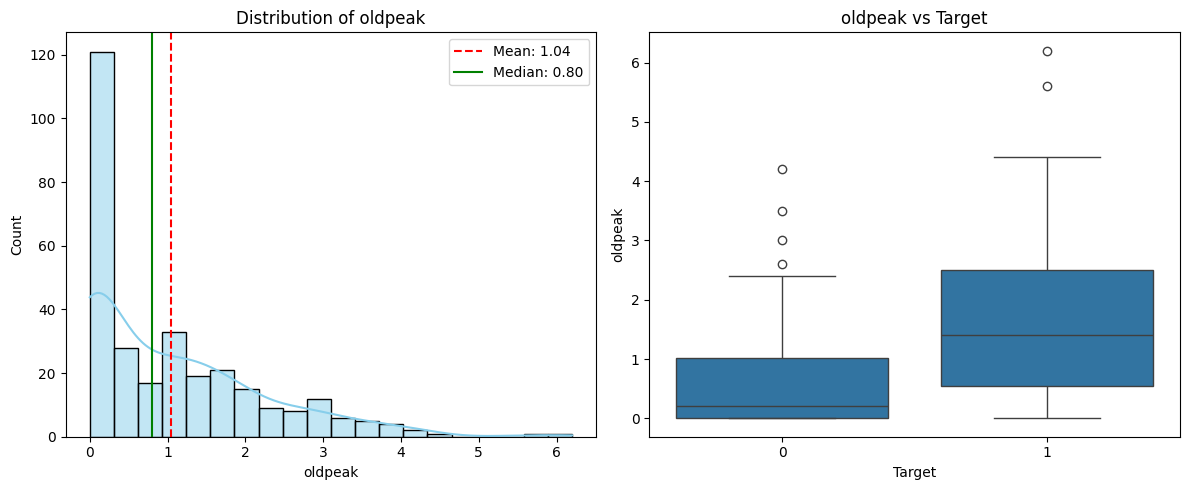

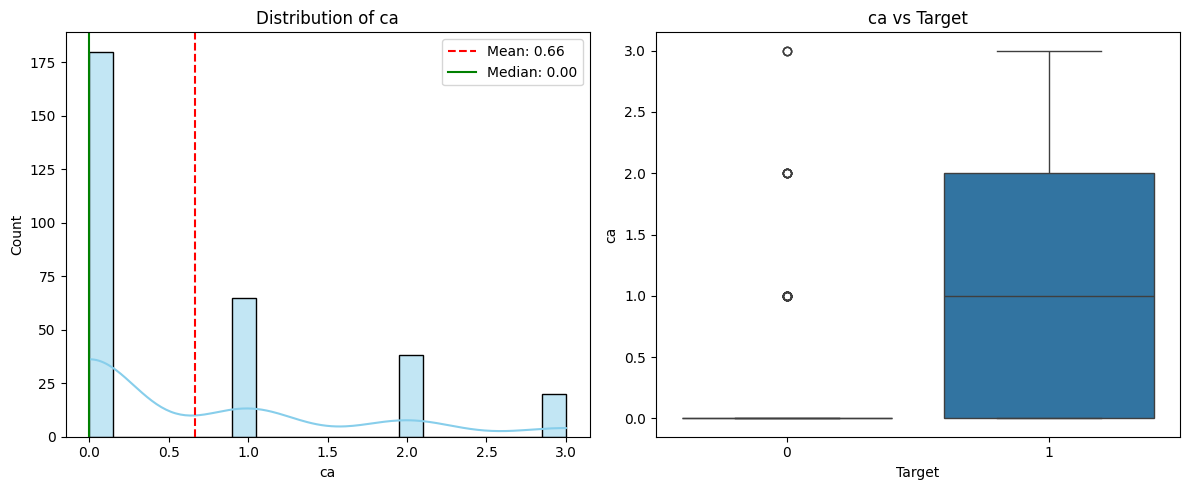

In [13]:
for col in num:
    plt.figure(figsize=(12,5))
    # Plot the distribution of numerical feature
    plt.subplot(1,2,1)
    sns.histplot(X[col], kde=True, bins=20, color='skyblue')
    mean_val = X[col].mean()
    median_val = X[col].median()
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    plt.title(f'Distribution of {col}')
    plt.legend()
    # Boxplot of numerical feature vs target
    plt.subplot(1,2,2)
    sns.boxplot(x=y['num'], y=X[col])
    plt.title(f'{col} vs Target')
    plt.xlabel('Target')
    plt.tight_layout()
    plt.show()

This analysis examines the distribution of each feature and how its values differ between healthy patients and those with heart disease.

* **age**: The distribution is near-normal, centered around 54 years. The boxplot shows that the heart disease group is generally older, with a higher median age than the healthy group.

* **trestbps (Resting Blood Pressure)**: The distribution is near-normal. The distributions for both classes are quite similar, both show a slightly higher presence of outliers (extreme high blood pressure).

* **chol (Cholesterol)**: Similar to blood pressure. While there are some outliers in both classes, the median cholesterol level is nearly close for both healthy and diseased patients in this specific dataset.

* **thalach (Max Heart Rate)**: There is a clear separation in the boxplot. Patients with heart disease tend to have significantly lower maximum heart rates compared to healthy individuals.

* **oldpeak (ST Depression)**: This feature is highly skewed toward zero. However, the boxplot shows that patients with heart disease typically have higher oldpeak values, marking it as a strong indicator of cardiac stress.

* **ca (Major Vessels)**: Most healthy patients have 0 major vessels colored by fluoroscopy. As the count increases, the likelihood of a heart disease diagnosis increases significantly, as shown by the much higher median.

### Categorical Features

* **sex:** Gender of the patient  
  * 1 = Male  
  * 0 = Female  

* **cp (chest pain type):** Type of chest pain experienced by the patient  
  * 1: Typical angina (strongly associated with heart disease)  
  * 2: Atypical angina  
  * 3: Non-anginal pain  
  * 4: Asymptomatic  

* **fbs:** Fasting blood sugar > 120 mg/dl  
  * 1 = True  
  * 0 = False  
  * Indicates potential presence of diabetes  

* **restecg:** Resting electrocardiographic results  
  * 0: Normal  
  * 1: ST-T wave abnormality (possible heart issues)  
  * 2: Left ventricular hypertrophy  

* **exang:** Exercise-induced angina  
  * 1 = Yes  
  * 0 = No  
  * Indicates chest pain during physical activity  

* **slope:** Slope of the peak exercise ST segment  
  * 1: Upsloping  
  * 2: Flat  
  * 3: Downsloping  

* **thal:** Thalassemia test result  
  * 3: Normal  
  * 6: Fixed defect  
  * 7: Reversible defect

In [14]:
# Categorical features
cat = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

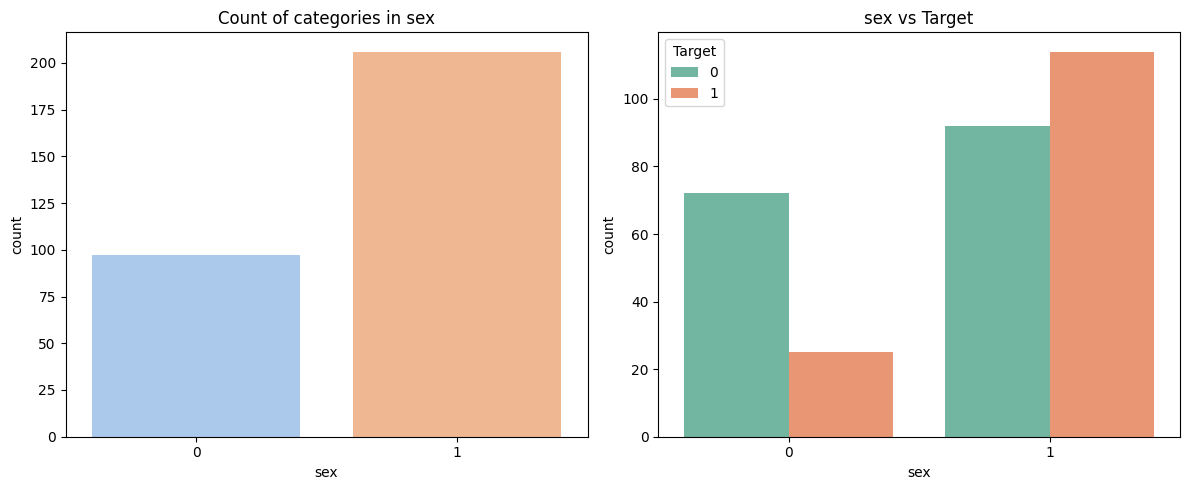

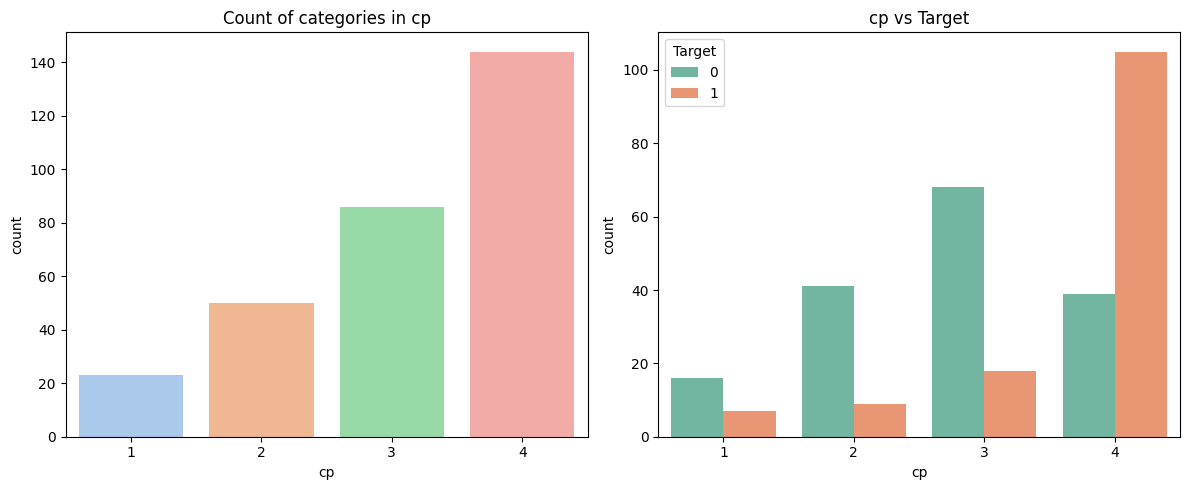

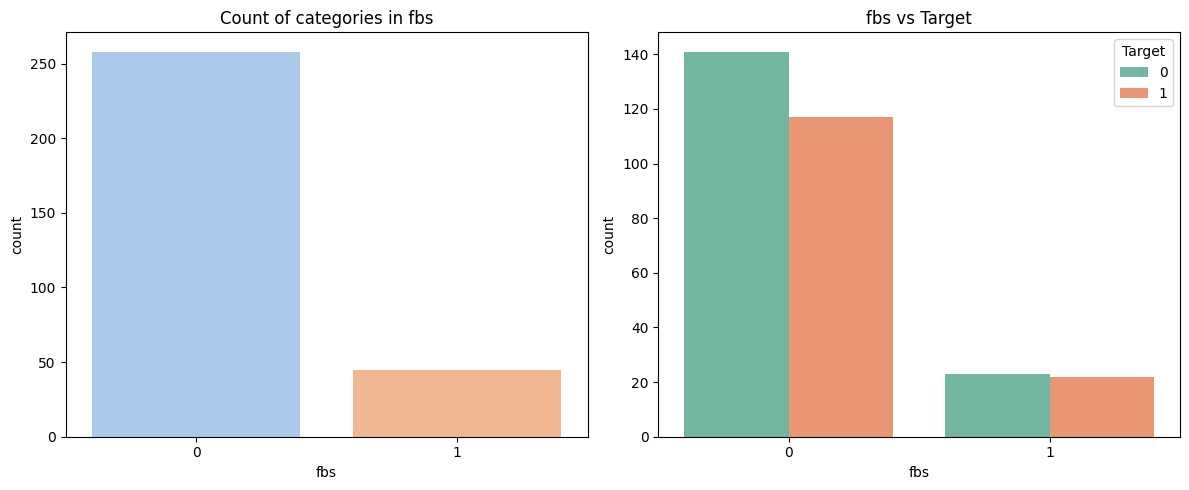

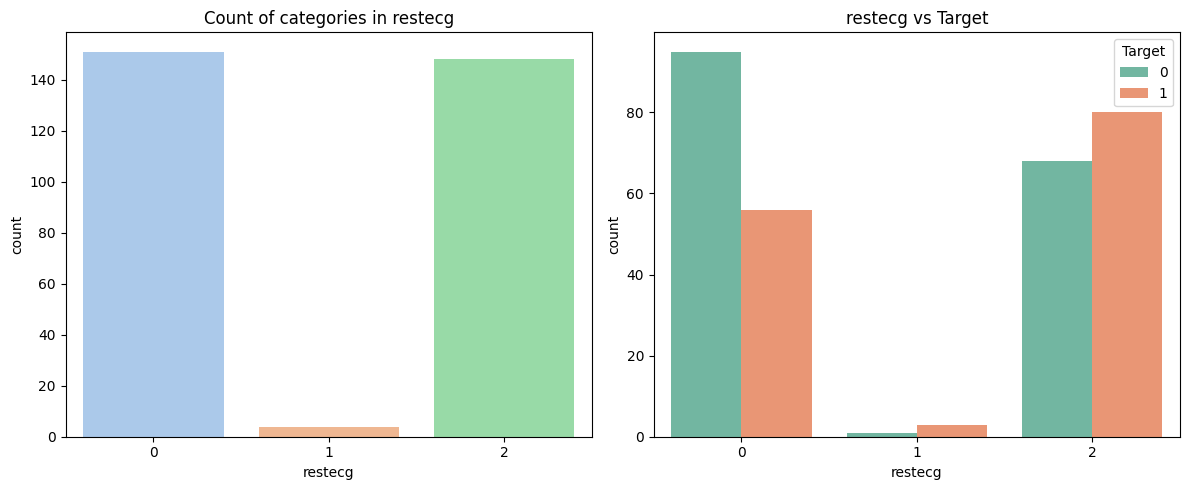

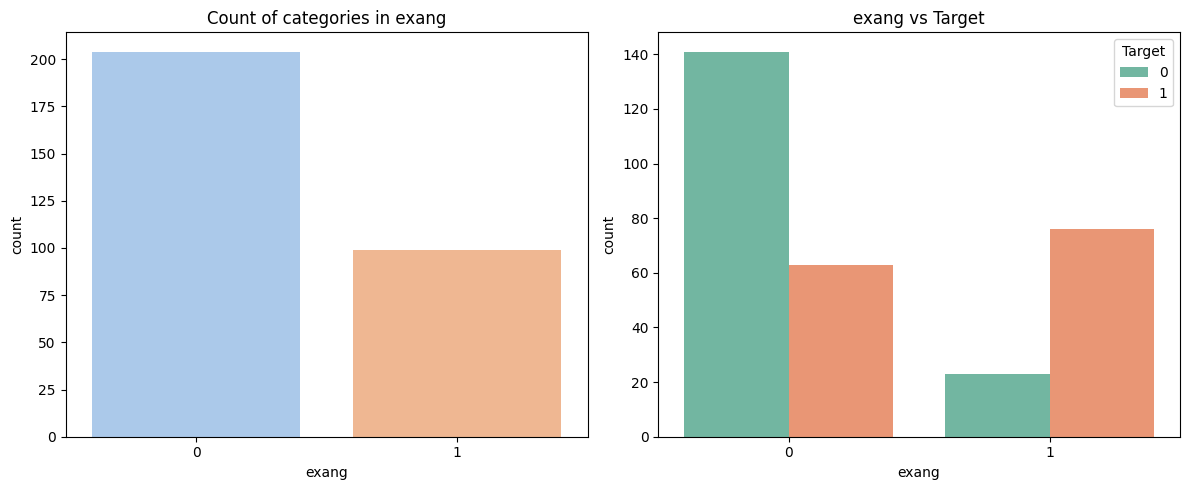

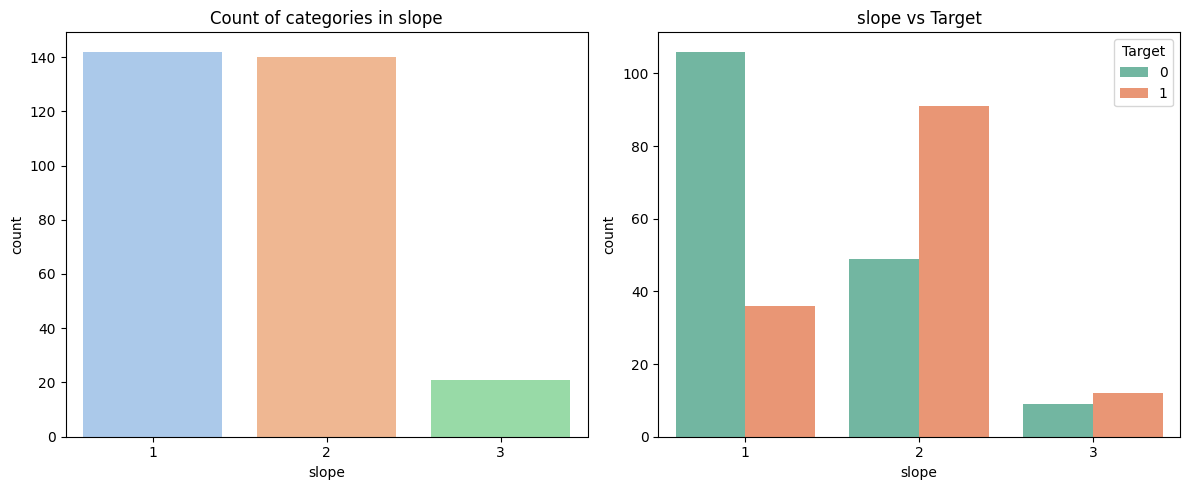

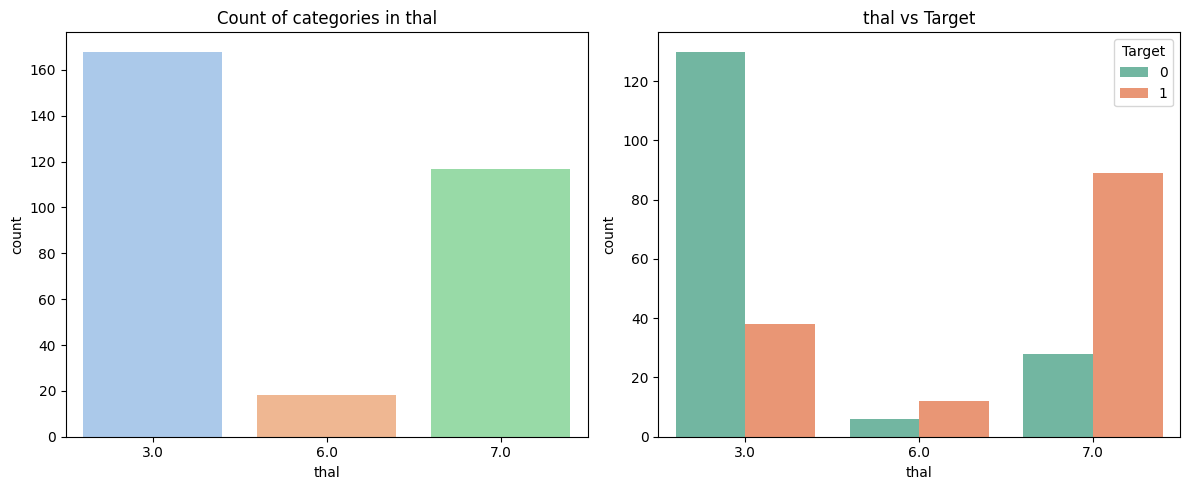

In [15]:
for col in cat:
    plt.figure(figsize=(12,5))
    # Plot the distribution of categorical feature
    plt.subplot(1,2,1)
    sns.countplot(x=X[col], palette='pastel')
    plt.title(f'Count of categories in {col}')
    # Plot the distribution of categorical feature vs target
    plt.subplot(1,2,2)
    sns.countplot(x=X[col], hue=y['num'], palette='Set2')
    plt.title(f'{col} vs Target')
    plt.legend(title='Target')
    plt.tight_layout()
    plt.show()

This analysis explores how categorical attributes are distributed and their relationship with heart disease.

* **sex**: The dataset contains significantly more male than female participants. Notably, the ratio of heart disease is much higher among the male population in this specific sample.

* **cp (Chest Pain Type)**: Patients with Type 4 show a disproportionately high frequency of heart disease. Conversely, those with Type 2 or 3 are more likely to be in the healthy group.

* **fbs (Fasting Blood Sugar)**: This feature shows the least differentiation. Most patients have low fasting blood sugar, and the ratio of heart disease to healthy patients is almost identical regardless of whether blood sugar is high or low.

* **restecg**: Most patients fall into Category 0 or 2. Category 2 (Left ventricular hypertrophy) shows a slightly higher count of heart disease cases than healthy cases.

* **exang (Exercise Induced Angina)**: There is a clear trend where patients who experience angina during exercise (1) are significantly more likely to have heart disease compared to those who do not (0).

* **slope**: Category 2 (Flat) shows a much higher ratio of heart disease cases than Category 1 (Upsloping).

* **thal (Thalassemia)**: Category 7.0 (Reversible defect) is a massive indicator, with a much higher count of heart disease patients compared to healthy ones. Category 3.0 (Normal) is heavily associated with healthy results.


### Target Variable

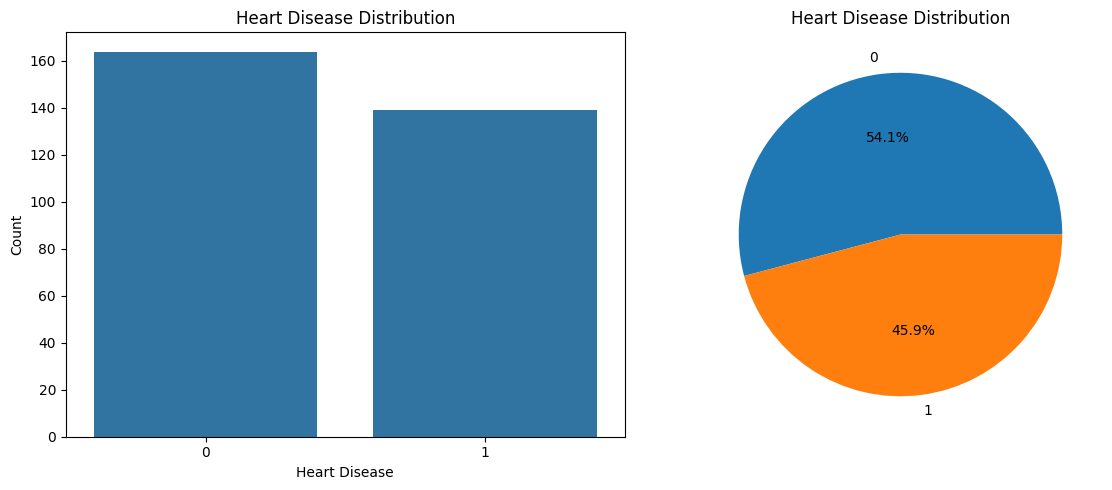

In [16]:
plt.figure(figsize=(12,5))
# Plot the distribution of target
plt.subplot(1, 2, 1)
sns.countplot(data=y, x='num')
plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
# Heart disease class distribution (pie chart)
plt.subplot(1, 2, 2)
counts = y['num'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title('Heart Disease Distribution')

plt.tight_layout()
plt.show()

The distribution of the target variable shows that cases of heart disease and healthy instances are almost equally represented across the dataset. This indicates there is no class imbalance, ensuring the model can learn both classes effectively without requiring specialized sampling techniques.

### Correlation Matrix

The Correlation Matrix provides a statistical summary of the strength and direction of linear relationships between variables, ranging from -1 to +1. We restrict this analysis to numerical features because mathematical correlation requires continuous data to calculate means and variances, which would yield misleading or undefined results if applied to categorical labels.

In [17]:
# Combine numerical features with target
df_corr = X[num].copy()
df_corr['target'] = y['num']

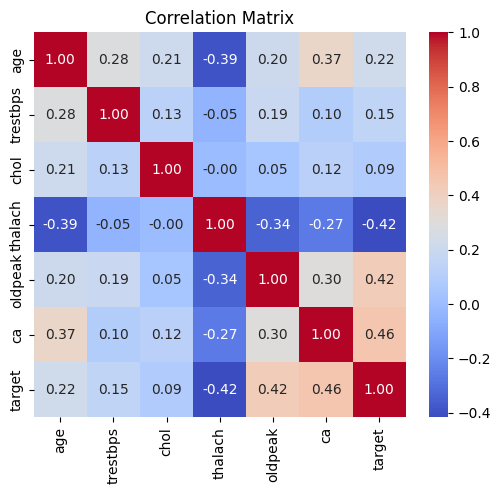

In [18]:
# Plot correlation matrix
plt.figure(figsize=(6,5))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The heatmap reveals that `ca (number of major vessels)`, `oldpeak (ST depression)`, and `thalach (maximum heart rate)` have the strongest correlations with the target variable, marking them as key numerical predictors.

Notably, `thalach` shows a significant negative correlation, suggesting that lower maximum heart rates are often associated with a higher likelihood of heart disease in this dataset.

Features like `ca` and `oldpeak` show the strongest positive linear relationships with the target, meaning as these values increase, the probability of heart disease typically rises.

Features like `chol` and `trestbps` show very weak correlations with the target, indicating that they may not be strong linear predictors when viewed in isolation.

There are no extremely high correlations between independent variables, which means we don't have redundant features that might confuse the model during training.

## 3. Modeling and Evaluation

Multiple machine learning models are trained on the dataset to learn patterns and relationships between features and the target variable. Models are evaluated to determine how well the model performs.

### Data Split and Standardization

The dataset is divided into training and testing sets to evaluate model performance on unseen data. This helps assess how well the model generalizes beyond the training data.

In [19]:
# Split the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y['num'], test_size=0.2, random_state=42, stratify=y['num'])

Standardization rescales numerical features to have a mean of 0 and a standard deviation of 1, ensuring all variables contribute equally to the model. It's performed after the train-test split to prevent data leakage to ensure parameters are derived from the training data.

In [20]:
# Create scaler and fit on train set
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [21]:
# Scale only numerical features
X_train_scaled[num] = scaler.fit_transform(X_train[num])
X_test_scaled[num] = scaler.transform(X_test[num])

### Implementation of Machine Learning Models

* **Logistic Regression** is a statistical model used for binary classification. It estimates the probability of a class using the logistic sigmoid function. It finds a linear combination of features that best separates the classes.

* **Random Forest** is an ensemble learning method that builds many decision trees and aggregates their predictions. Each tree is trained on a random subset of data and features. Final prediction is made by majority voting.

* **Support Vector Classifier** is a classifier that finds the optimal boundary separating classes. It maximizes the margin between classes. It could handle use kernels to handle non-linear separations in feature space.

* **XGBoost** is a gradient boosting algorithm that builds trees sequentially, each correcting errors of the previous ones.It focuses on minimizing a loss function using gradient descent. It's highly efficient and often provides strong predictive performance.

In [22]:
# Model definition
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVC': SVC(probability=True, random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

### Hyperparameter Tuning using GridSearchCV

* Hyperparameter tuning consists of selecting the best configuration of a model (parameters set before training) in order to improve its performance and generalization.

* GridSearchCV is a technique used to find the best hyperparameters for a model by testing multiple combinations of parameter values. It automates the process of trying different settings and comparing their performance.
  * It uses a method called cross-validation, where the dataset is split into several parts called folds.

  * In each iteration, the model is trained on most of the data and tested on the remaining part. This process is repeated so that each fold is used once as a test set.
  
  * The performance is then averaged across all folds, which gives a more reliable evaluation of the model and helps avoid overfitting.

  * Finally, GridSearchCV selects the combination of hyperparameters that achieves the best average performance across all folds.

In [23]:
# Hyperparameters for model tuning
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5, 10]
    },
    'SVC': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    }
}

In [24]:
# Store best models and results
best_models = {}
results = []

Evaluation Methods:
* **Accuracy:** The proportion of correctly predicted samples out of all samples. While useful for balanced datasets, accuracy can be misleading if the classes are imbalanced (e.g., many more healthy cases than disease cases).

* **Precision:** Of all the samples predicted as positive (presence of disease), how many are actually positive. High precision means few false positives.

* **Recall (Sensitivity):** Of all actual positive samples, how many were correctly predicted as positive. High recall means few false negatives, which is especially important in medical diagnosis.

* **F1 Score:** The harmonic mean of precision and recall. It provides a balance between the two, particularly useful when the dataset is imbalanced.

* **AUC (Area Under the ROC Curve):** Measures the model’s ability to distinguish between the two classes (disease vs. no disease) across all classification thresholds. Higher AUC indicates better separability.

* **Confusion Matrix:** A table summarizing the model’s predictions versus actual labels. It shows true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN), giving a complete view of model performance.

Training Logistic Regression Model ...


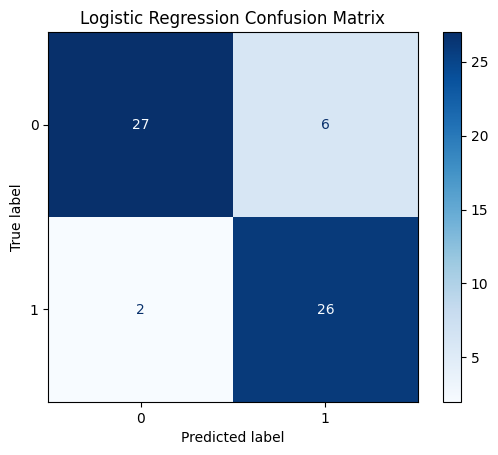

Training Random Forest Model ...


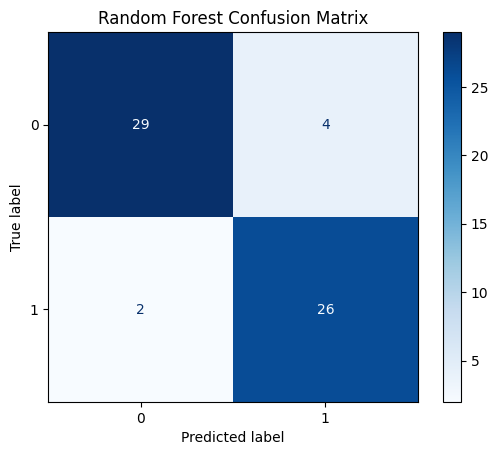

Training SVC Model ...


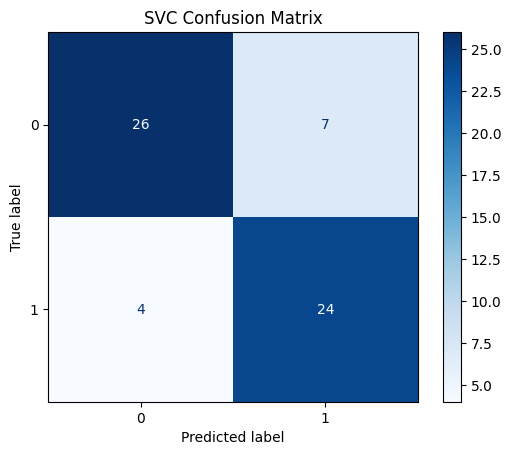

Training XGBoost Model ...


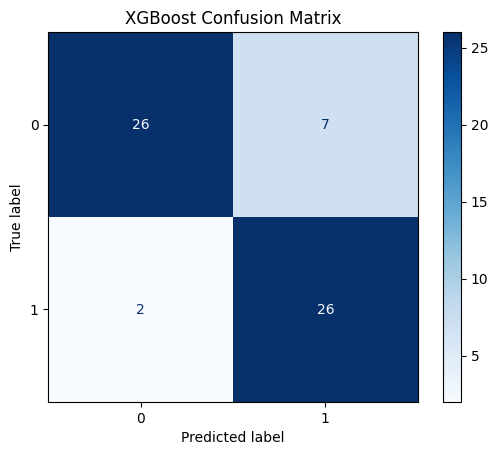

In [25]:
for name in models:
    # Train with GridSearchCV
    print(f"Training {name} Model ...")
    grid = GridSearchCV(
        models[name], param_grids[name], cv=5, scoring='roc_auc', n_jobs=-1
    )

    # Fit model and save best model
    grid.fit(X_train_scaled, y_train)
    best_models[name] = grid.best_estimator_

    # Predictions
    y_pred = grid.predict(X_test_scaled)
    y_prob = grid.predict_proba(X_test_scaled)[:,1] if hasattr(grid, "predict_proba") else grid.decision_function(X_test_scaled)

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # Store results
    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'AUC': auc
    })

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

The performance of different models is compared to select the most suitable one. This ensures that the final choice is based on objective evaluation rather than assumption.

In [26]:
# Create and display results
results_df = pd.DataFrame(results)
results_df

,Model,Best Params,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,"{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}",0.868852,0.812500,0.928571,0.866667,0.949134
1,Random Forest,"{'max_depth': 5, 'min_samples_split': 5, 'n_es...",0.901639,0.866667,0.928571,0.896552,0.955628
2,SVC,"{'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}",0.819672,0.774194,0.857143,0.813559,0.919913
3,XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.852459,0.787879,0.928571,0.852459,0.927489


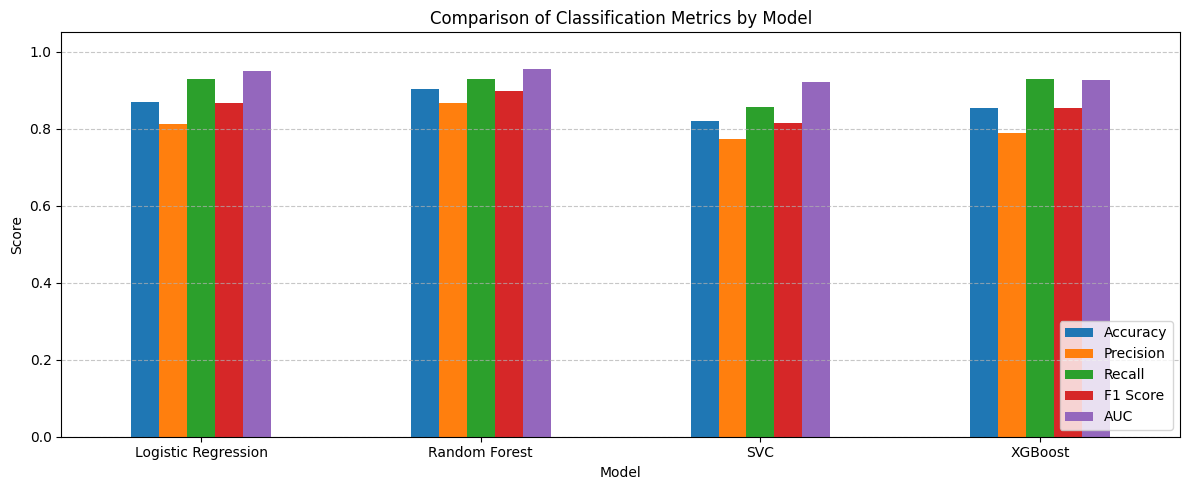

In [27]:
# Plot the result
fig, ax = plt.subplots(figsize=(12,5))
results_df.plot(x='Model', kind='bar', ax=ax, rot=0)
plt.title('Comparison of Classification Metrics by Model')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

* **Random Forest** demonstrated the strongest overall performance. Its predictions show a well-balanced capability, accurately distinguishing between disease and healthy cases while effectively minimizing both false positives and false negatives. This balance makes it a reliable choice for practical application.

* **Logistic Regression** also performed effectively, showing strength in identifying patients with heart disease. While it is slightly more prone to generating false positives compared to Random Forest, its ability to detect most cases makes it a viable alternative, especially when model interpretability is a priority.

* **XGBoost** showed strong detection of heart disease cases, highlighting its sensitivity to positive instances. However, it is somewhat more prone to misclassifying healthy cases, which can lead to an increase in false positives.

* **SVC** displayed moderate performance relative to the other models. Its predictions occasionally miss positive cases and incorrectly classify some healthy cases as disease, indicating less balanced reliability.

Considering the overall behavior of the models, Random Forest emerges as the most balanced and dependable model for heart disease classification. Logistic Regression offers a simpler, more interpretable alternative, while XGBoost and SVC provide additional perspectives with trade-offs in balance and accuracy.

## 4. Model Interpretation

### Feature Importance

Feature importance analysis is conducted to identify which variables contribute most to predictions. This improves interpretability and provides insights into key factors influencing heart disease.

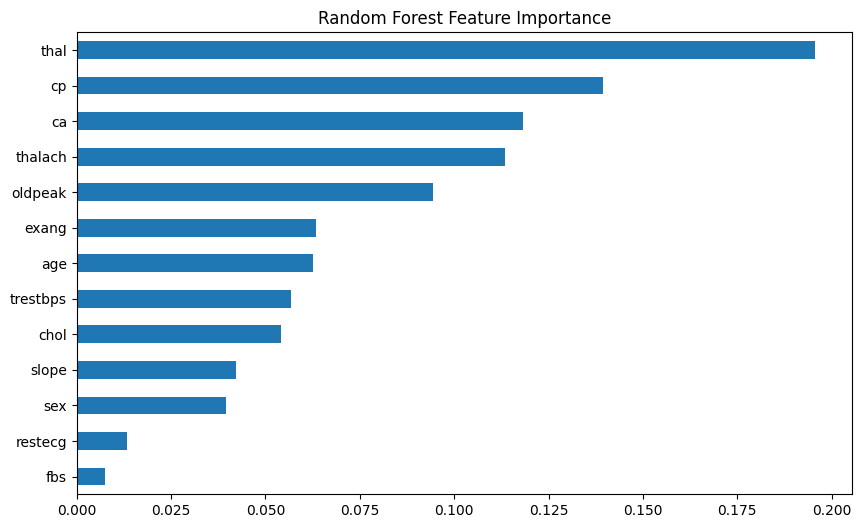

In [28]:
# Random Forest feature importance
rf = best_models['Random Forest']
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train_scaled.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Random Forest Feature Importance")
plt.show()

The Random Forest model identifies the most influential features for predicting heart disease in this dataset. Among the predictors, `thal (Thalassemia)`, `cp (Chest Pain Type)`, `ca (Number of Major Vessels)`, `thalach (Maximum Heart Rate)`, `oldpeak (ST Depression)`, and `exang (Exercise-Induced Angina)` emerge as the most important, indicating that these variables carry the most information regarding the presence of heart disease.

* **Thal (Thalassemia)** is the strongest predictor, highlighting that reversible defects in the heart, as captured by thalassemia testing, are highly indicative of disease risk.
* **Chest Pain Type (cp)** also shows high importance, reflecting the clinical relevance of pain patterns in diagnosing heart conditions.
* **Number of Major Vessels (ca)** and **ST Depression (oldpeak)** demonstrate strong predictive power, consistent with our earlier EDA observations that higher values in these features are associated with heart disease.
* **Maximum Heart Rate (thalach)** is inversely related to disease presence, confirming that lower achievable heart rates during stress tests are a key indicator.
* **Exercise-Induced Angina (exang)** reinforces the importance of symptom manifestation under exertion in assessing cardiovascular risk.

Secondary features such as `age`, `resting blood pressure (trestbps)`, `cholesterol (chol)`, `slope`, `sex`, `restecg`, and `fasting blood sugar (fbs)` have lower relative importance. While they contribute to the model, their predictive power is less pronounced, suggesting that these features alone are weaker indicators of disease risk but may provide additional context when combined with stronger predictors.



Overall, the feature importance analysis aligns closely with both the univariate and correlation analyses conducted during the EDA. The top predictors are highly interpretable from a clinical perspective, emphasizing physiological measurements and symptom indicators that are known to be strongly associated with heart disease. This reinforces the validity of the dataset and provides a clear rationale for model-driven predictions.

In [29]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))